# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Agbay, Tristan Michael
- _Student No._: 2024-00281
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

By the fundamental theorem of algebra, since the highest degree of the function is 5, it would lead us to expect that the function has up to 5 roots. 

Note that the function can be rearranged and factored out to obtain the form

$$
f(x) = (x - 2)^2 (e^x - x^3 - 2)
$$

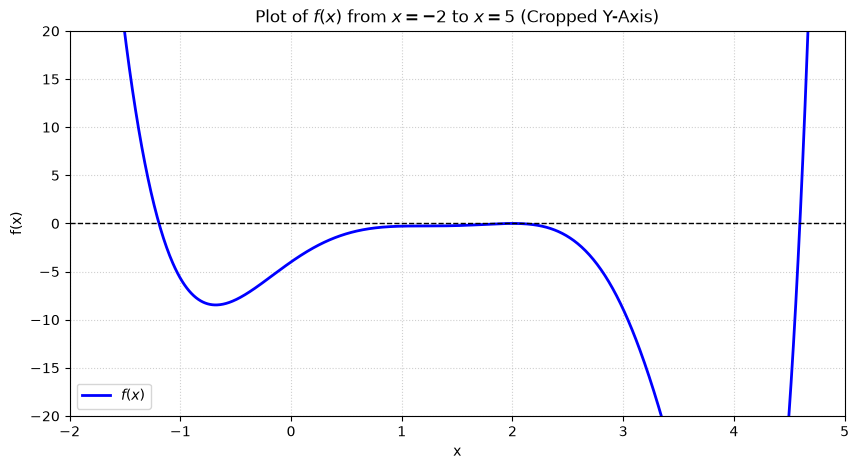

In [39]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Original function f(x)
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*math.exp(x) - 2*x**2 - 4*x*math.exp(x) + 8*x + 4*math.exp(x) - 8

# Analytical derivative f'(x)
def df(x):
    return -5*x**4 + 16*x**3 - 12*x**2 - 4*x + 8 + (x**2 - 2*x)*math.exp(x)

# Fixed-Point Iteration Functions g(x)
def g_A(x):
    # Isolating 8x -> g_A(x) (Used for Region 2 near x ≈ 2)
    return (x**5 - 4*x**4 + 4*x**3 - (x**2)*math.exp(x) + 2*x**2 + 4*x*math.exp(x) - 4*math.exp(x) + 8) / 8.0

def g_B(x):
    # Isolating e^x (x-2)^2 -> g_B(x) = ln(...) (Used for Region 3 near x ≈ 4.6)
    num = x**5 - 4*x**4 + 4*x**3 + 2*x**2 - 8*x + 8
    denom = (x - 2)**2
    val = num / denom if denom != 0 else 1e-12
    return math.log(val) if val > 0 else 0


# Generate x grid from -2 to 5 to inspect function behavior
x_vals = np.linspace(-2, 5, 1000)
y_vals = np.array([f(x) for x in x_vals])

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label=r"$f(x)$", color="blue", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# Crop y-axis to observe axis crossings clearly
plt.ylim(-20, 20)
plt.xlim(-2, 5)

plt.title("Plot of $f(x)$ from $x = -2$ to $x = 5$ (Cropped Y-Axis)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig("7plot.png")
plt.show()


Visual observations from the plot:
Region 1: Graph crosses y = 0 in the interval [-2, 0] (around x ≈ -1)
Region 2: Graph touches or stays tangent to y = 0 in the interval around x ≈ 2
Region 3: Graph crosses y = 0 in the interval [4, 5] (around x ≈ 4.5)

In [40]:
def fixed_point(g, x0, tol=1e-6, max_iter=100):
    history = [x0]
    x = x0
    for _ in range(max_iter):
        x_next = g(x)
        history.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return history[-1], history

In [41]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    history = []
    fa, fb = f(a), f(b)
    if fa * fb >= 0:
        print(f"Bisection failed on interval [{a}, {b}]: f(a) * f(b) >= 0 (no sign change).")
        return None, history
        
    for _ in range(max_iter):
        c = (a + b) / 2.0
        history.append(c)
        fc = f(c)
        if abs(fc) < tol or (b - a) / 2.0 < tol:
            break
        if fc * fa < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return history[-1], history

In [42]:
def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
    history = [x0]
    x = x0
    for _ in range(max_iter):
        fx = f(x)
        dfx = df(x)
        if abs(fx) < tol:
            break
        if dfx == 0:
            print("Newton-Raphson failed: Derivative is zero.")
            break
        x = x - fx / dfx
        history.append(x)
    return history[-1], history

In [43]:
def secant(f, x0, x1, tol=1e-6, max_iter=100):
    history = [x0, x1]
    for _ in range(max_iter):
        f0 = f(history[-2])
        f1 = f(history[-1])
        if abs(f1) < tol or abs(f1 - f0) < 1e-12:
            break
        x2 = history[-1] - f1 * (history[-1] - history[-2]) / (f1 - f0)
        history.append(x2)
    return history[-1], history

In [47]:
# searched 3 different regions based on visual plot of f(x) to try to pin down the roots, I did this because I deemed it to be more interesting to see three separate plots
# given the interval of [-2,5]


# region 1: Interval [-2, 0], initial guesses around x = -1.0 
print("--- Region 1 ---")
r1_bis,  h1_bis  = bisection(f, a=-2.0, b=0.0)
r1_newt, h1_newt = newton_raphson(f, df, x0=-1.0)
r1_sec,  h1_sec  = secant(f, x0=-1.5, x1=-0.5)

# region 2: Interval [1, 3], initial guesses around x = 1.5 
print("\n--- Region 2 ---")
r2_bis,  h2_bis  = bisection(f, a=1.0, b=3.0)  # Fails due to no sign change
r2_fp,   h2_fp   = fixed_point(g_A, x0=1.9)
r2_newt, h2_newt = newton_raphson(f, df, x0=1.5)
r2_sec,  h2_sec  = secant(f, x0=1.5, x1=2.5)

# region 3: Interval [4, 5], initial guesses around x = 4.0 
print("\n--- Region 3 ---")
r3_bis,  h3_bis  = bisection(f, a=4.0, b=5.0)
r3_fp,   h3_fp   = fixed_point(g_B, x0=4.0)
r3_newt, h3_newt = newton_raphson(f, df, x0=4.8) 
r3_sec,  h3_sec  = secant(f, x0=4.0, x1=4.8)

print("\n--- Summary of Discovered Roots ---")
print(f"Region 1 Root: {r1_newt:.6f}")
print(f"Region 2 Root: {r2_newt:.6f}")
print(f"Region 3 Root: {r3_newt:.6f}")

--- Region 1 ---

--- Region 2 ---
Bisection failed on interval [1.0, 3.0]: f(a) * f(b) >= 0 (no sign change).

--- Region 3 ---

--- Summary of Discovered Roots ---
Region 1 Root: -1.192686
Region 2 Root: 2.000480
Region 3 Root: 4.595864


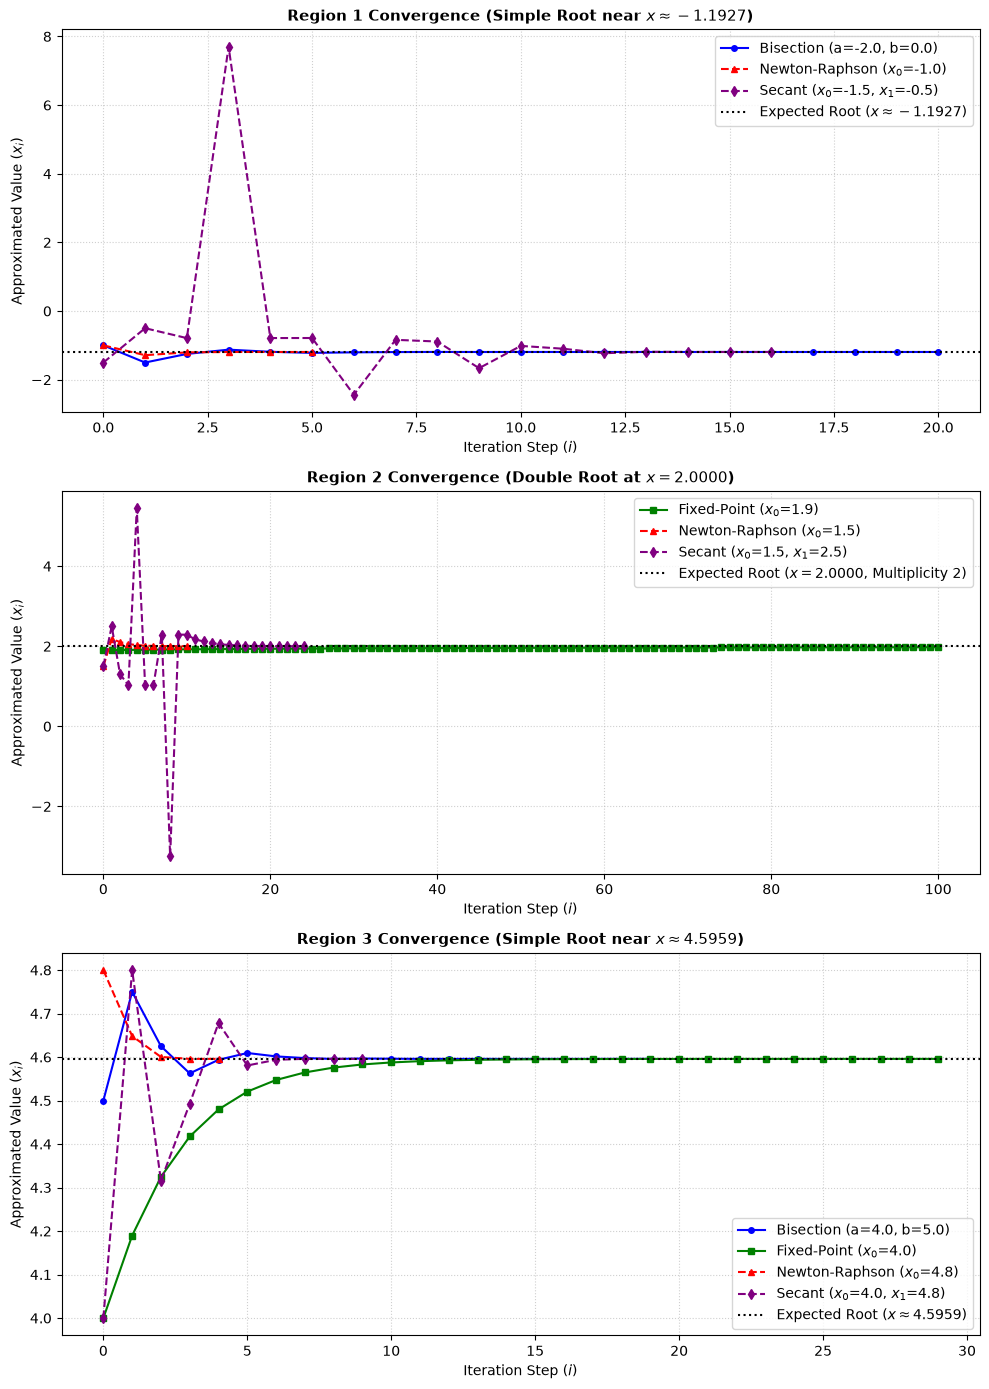

In [50]:
# plot plot plot
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

# Region 1 Convergence
axes[0].plot(range(len(h1_bis)), h1_bis, 'o-', label="Bisection (a=-2.0, b=0.0)", color="blue", markersize=4)
axes[0].plot(range(len(h1_newt)), h1_newt, '^--', label="Newton-Raphson ($x_0$=-1.0)", color="red", markersize=5)
axes[0].plot(range(len(h1_sec)), h1_sec, 'd--', label="Secant ($x_0$=-1.5, $x_1$=-0.5)", color="purple", markersize=5)

# Expected theoretical root line
axes[0].axhline(y=-1.192686, color="black", linestyle=":", linewidth=1.5, label="Expected Root ($x \\approx -1.1927$)")

axes[0].set_title("Region 1 Convergence (Simple Root near $x \\approx -1.1927$)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Iteration Step ($i$)")
axes[0].set_ylabel("Approximated Value ($x_i$)")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper right")

# Region 2 Convergence (root with multiplicity 2 region where bisection failed)
if len(h2_fp) > 0:
    axes[1].plot(range(len(h2_fp)), h2_fp, 's-', label="Fixed-Point ($x_0$=1.9)", color="green", markersize=4)
axes[1].plot(range(len(h2_newt)), h2_newt, '^--', label="Newton-Raphson ($x_0$=1.5)", color="red", markersize=5)
axes[1].plot(range(len(h2_sec)), h2_sec, 'd--', label="Secant ($x_0$=1.5, $x_1$=2.5)", color="purple", markersize=5)

# Expected theoretical root line
axes[1].axhline(y=2.000000, color="black", linestyle=":", linewidth=1.5, label="Expected Root ($x = 2.0000$, Multiplicity 2)")

axes[1].set_title("Region 2 Convergence (Double Root at $x = 2.0000$)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Iteration Step ($i$)")
axes[1].set_ylabel("Approximated Value ($x_i$)")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="upper right")

# Region 3 Convergence
axes[2].plot(range(len(h3_bis)), h3_bis, 'o-', label="Bisection (a=4.0, b=5.0)", color="blue", markersize=4)
axes[2].plot(range(len(h3_fp)), h3_fp, 's-', label="Fixed-Point ($x_0$=4.0)", color="green", markersize=4)
axes[2].plot(range(len(h3_newt)), h3_newt, '^--', label="Newton-Raphson ($x_0$=4.8)", color="red", markersize=5)
axes[2].plot(range(len(h3_sec)), h3_sec, 'd--', label="Secant ($x_0$=4.0, $x_1$=4.8)", color="purple", markersize=5)

# Expected theoretical root line
axes[2].axhline(y=4.595864, color="black", linestyle=":", linewidth=1.5, label="Expected Root ($x \\approx 4.5959$)")

axes[2].set_title("Region 3 Convergence (Simple Root near $x \\approx 4.5959$)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Iteration Step ($i$)")
axes[2].set_ylabel("Approximated Value ($x_i$)")
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.savefig("convergence")
plt.show()

Short discussion to be included in the better report

In the graph we have

1. a and b: The lower and upper boundaries of the bracket interval $[a, b]$ required by the Bisection method. Bisection requires $f(a)$ and $f(b)$ to have opposite signs.
2. ($x_0$): The initial starting point (first guess) for open, single-point methods (Newton-Raphson and fixed-point iteration).
3. ($x_1$): The second initial point required by the Secant method, as it approximates the slope of the function using two initial points instead of requiring an analytical derivative
4. $f'(x)$.h1_..., h2_..., h3_...: Lists tracking the step-by-step history of approximated root values ($x_i$) across iteration steps for Regions 1, 2, and 3


Simple Roots (Regions 1 & 3): Newton-Raphson and Secant demonstrate rapid (quadratic/superlinear) convergence, flattening out onto the target line within 5–15 iterations. Bisection displays linear, stepwise convergence, requiring roughly 20 iterations to reach tolerance.

2nd Order Root (Region 2, $x = 2.0$): Because $f'(2) = 0$, Newton-Raphson loses its quadratic convergence speed and degrades to linear convergence, taking noticeably more iterations to arrive at $x = 2.0$. Bisection is omitted because $f(x)$ touches zero without crossing it, violating the sign-change assumption $f(a) \cdot f(b) < 0$.

#### Problem 1 code summary



---